In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
train_images = train_images / 255.0
test_images = test_images / 255.0

train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

In [4]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

C:\ProgramData\anaconda3\envs\dsml37_env1\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [6]:
history = model.fit(train_images, train_labels, epochs=10, validation_data=(test_images, test_labels))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 18ms/step - accuracy: 0.7469 - loss: 0.6996 - val_accuracy: 0.8639 - val_loss: 0.3835
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8767 - loss: 0.3354 - val_accuracy: 0.8857 - val_loss: 0.3211
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8966 - loss: 0.2788 - val_accuracy: 0.8920 - val_loss: 0.2948
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9066 - loss: 0.2509 - val_accuracy: 0.8965 - val_loss: 0.2903
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9155 - loss: 0.2253 - val_accuracy: 0.8999 - val_loss: 0.2713
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9247 - loss: 0.2000 - val_accuracy: 0.9038 - val_loss: 0.2642
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9347 - loss: 0.1782 - val_accuracy: 0.9026 - val_loss: 0.2767
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9385 -

In [7]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9071 - loss: 0.2972
Test Accuracy: 0.9085999727249146


In [8]:
predictions = model.predict(test_images)

import numpy as np
print("Predicted:", np.argmax(predictions[0]))
print("Actual:", test_labels[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Predicted: 9
Actual: 9


In [9]:
class_names = [
    "T-shirt/top",   # 0
    "Trouser",       # 1
    "Pullover",      # 2
    "Dress",         # 3
    "Coat",          # 4
    "Sandal",        # 5
    "Shirt",         # 6
    "Sneaker",       # 7
    "Bag",           # 8
    "Ankle boot"     # 9
]

In [10]:
import numpy as np
predicted_label = np.argmax(predictions[0])
actual_label = test_labels[0]
print("Predicted:", predicted_label, "-", class_names[predicted_label])
print("Actual:", actual_label, "-", class_names[actual_label])

Predicted: 9 - Ankle boot
Actual: 9 - Ankle boot


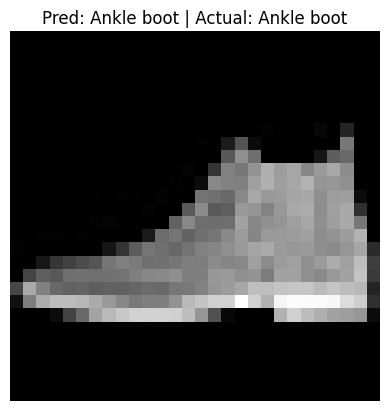

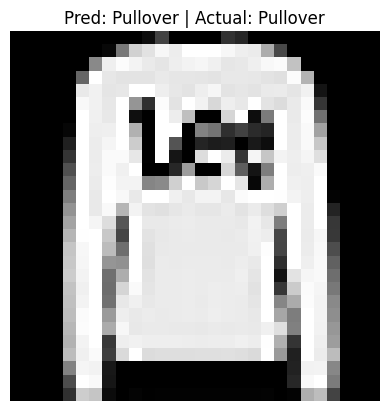

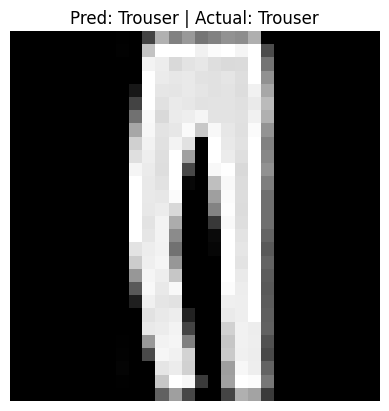

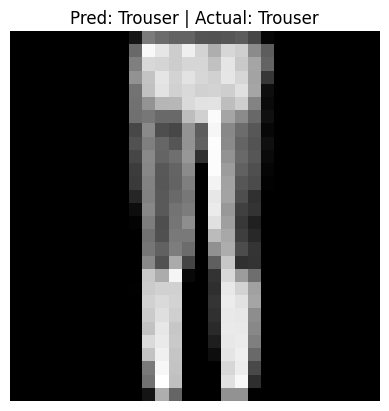

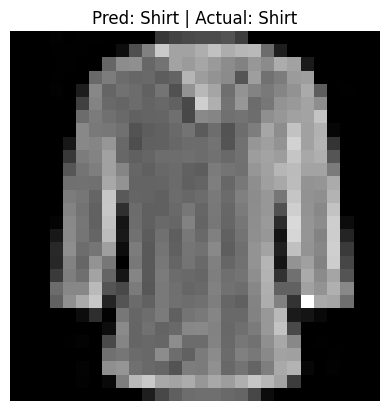

In [11]:
import matplotlib.pyplot as plt
for i in range(5):
    plt.imshow(test_images[i].reshape(28,28), cmap='gray')
    
    pred = np.argmax(predictions[i])
    actual = test_labels[i]
    
    plt.title(f"Pred: {class_names[pred]} | Actual: {class_names[actual]}")
    plt.axis('off')
    plt.show()

In [18]:
from tensorflow.keras.preprocessing import image
img = image.load_img("shirt.jpg", target_size=(28,28), color_mode='grayscale')
img = image.img_to_array(img)
img = img/255.0

img = 1 - img

img = img.reshape(1,28,28,1)
pred = model.predict(img)

predicted_label = np.argmax(pred)
predicted_class = class_names[predicted_label]

print("Predicted Label:", predicted_label)
print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Label: 6
Predicted Class: Shirt
